# Soluciones a las tareas planteadas de la práctica 2

Antes que nada, ejecutar esta primera celda para importar todo bien.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo de píxeles blancos en una fila (maxfil): 0.4296875
Filas con al menos el 90% de maxfil (0.38671875 píxeles): [  6  12  15  20  21  88 100]


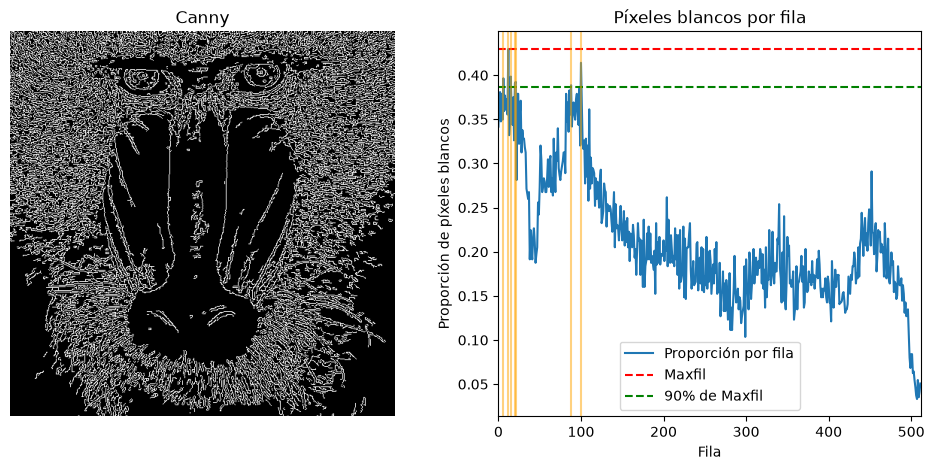

In [3]:
img = cv2.imread('mandril.jpg') #para leer la imagen
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # converitmos la imagen a gris
canny = cv2.Canny(gris, 100, 200) #es para identificar los bordes de la imagen, ya que funciona solo cpn el escalado en gris
count_rows = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1) #suma las filas 
rows = count_rows[:] / (255 * canny.shape[1]) #esta normalizando,  es decir haciendolo mas peque;o  para que se muestre en la grafica

maxfil = rows.max() # la mayor proporcion encontrada en cualquier file
umbral = maxfil * 0.9 #aqui calculamos el umbral
filas_destacadas = np.where(rows >= umbral)[0] # indice (numero de fila) cuya proprición >= umbral
print(f"Valor máximo de píxeles blancos en una fila (maxfil): {maxfil}")
print(f"Filas con al menos el 90% de maxfil ({umbral} píxeles): {filas_destacadas}")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1) # crea un lienzo con una fila y 2 columnas
plt.axis("off") # oculta los ejes para mostrar solo la imagen
plt.title("Canny") #titulo
plt.imshow(canny, cmap='gray') #muestra la imagen en escala de grises

plt.subplot(1, 2, 2) # en la imagen de la derecha
plt.title("Píxeles blancos por fila")
plt.xlabel("Fila")
plt.ylabel("Proporción de píxeles blancos")
plt.plot(rows, label="Proporción por fila") #dibuja la curva de rows

plt.axhline(maxfil, color="red", linestyle="--", label="Maxfil") # una linea roja horizontal en proporcion a la maxima encontrada
plt.axhline(0.9*maxfil, color="green", linestyle="--", label="90% de Maxfil")# una linea verde horizontal en el 90% de esa proporicon

for f in filas_destacadas: # dibuja lineas verticales en las filas que superarion el umbral 
    plt.axvline(f, color="orange", alpha=0.5)
plt.xlim([0, canny.shape[0]])
plt.legend()
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

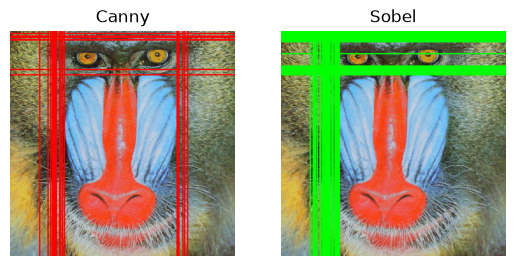

Máximo de filas Sobel 0.69921875
Máximo de filas Canny 0.4296875
Máximo de columnas Sobel 0.662109375
Máximo de columnas Canny 0.365234375


In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convierte a RGB
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)# convierte a gris
canny = cv2.Canny(gris, 100, 200) 

# análisis Canny original
col_counts_canny = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_canny = col_counts_canny[0] / (255 * canny.shape[0])
#suma sobre filas, resultado = cantidad de píxeles blancos por columna.
row_counts_canny = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows_canny = row_counts_canny[:, 0] / (255 * canny.shape[1])
#suma sobre columnas, resultado = cantidad de píxeles blancos por fila.
# procesamiento Sobel
ggris = cv2.GaussianBlur(gris, (3, 3), 0)# suavizar los bordes
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  #  gradiente en X
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # gradiente en Y
sobel = cv2.add(sobelx, sobely) #combina ambos
sobel8 = cv2.convertScaleAbs(sobel)

# umbralizado de sobel
valorUmbral_sobel = 50  # valor ajustado para Sobel
_, sobel_umbral = cv2.threshold(sobel8, valorUmbral_sobel, 255, cv2.THRESH_BINARY)# umbraliza para quedanos con pixeles fueres

# conteo por columnas y filas para Sobel umbralizado
col_counts_sobel = cv2.reduce(sobel_umbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_sobel = col_counts_sobel[0] / (255 * sobel_umbral.shape[0])

row_counts_sobel = cv2.reduce(sobel_umbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
rows_sobel = row_counts_sobel[:, 0] / (255 * sobel_umbral.shape[1])

# encontrar máximos y umbrales (90% del máximo)
# así puedes detectar no solo la fila/columna con el máximo, sino también todas las que están muy cercanas al máximo.
max_col_canny = np.max(cols_canny)
max_row_canny = np.max(rows_canny)
umbral_col_canny = 0.90 * max_col_canny
umbral_row_canny = 0.90 * max_row_canny

max_col_sobel = np.max(cols_sobel)
max_row_sobel = np.max(rows_sobel)
umbral_col_sobel = 0.90 * max_col_sobel
umbral_row_sobel = 0.90 * max_row_sobel

# encontrar columnas y filas por encima del umbral
cols_destacadas_canny = np.where(cols_canny > umbral_col_canny)[0]
rows_destacadas_canny = np.where(rows_canny > umbral_row_canny)[0]

cols_destacadas_sobel = np.where(cols_sobel > umbral_col_sobel)[0]
rows_destacadas_sobel = np.where(rows_sobel > umbral_row_sobel)[0]

# crear imágenes con marcas
img_marked_canny = img_rgb.copy()
img_marked_sobel = img_rgb.copy()

# marcar líneas destacadas en Canny (rojo)
for col in cols_destacadas_canny:
    cv2.line(img_marked_canny, (col, 0), (col, img_marked_canny.shape[0]), (255, 0, 0), 2)
for row in rows_destacadas_canny:
    cv2.line(img_marked_canny, (0, row), (img_marked_canny.shape[1], row), (255, 0, 0), 2)

# marcar líneas destacadas en Sobel (verde)
for col in cols_destacadas_sobel:
    cv2.line(img_marked_sobel, (col, 0), (col, img_marked_sobel.shape[0]), (0, 255, 0), 2)
for row in rows_destacadas_sobel:
    cv2.line(img_marked_sobel, (0, row), (img_marked_sobel.shape[1], row), (0, 255, 0), 2)

# visualización completa
plt.figure()

plt.subplot(1,2,1)
plt.axis("off")
plt.title("Canny")
plt.imshow(img_marked_canny, cmap='gray')

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Sobel")
plt.imshow(img_marked_sobel, cmap='gray')

plt.show()

print("Máximo de filas Sobel", max_row_sobel)
print("Máximo de filas Canny", max_row_canny)

print("Máximo de columnas Sobel", max_col_sobel)
print("Máximo de columnas Canny", max_col_canny)

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
def crea_eliminador_fondo():
    return cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)

# devuelve, por columna, si hay suficiente movimiento (fracción de píxeles >= umbral).
def columnas_con_movimiento(mascara, umbral_actividad=0.05):
    alto, ancho = mascara.shape
    # reutiliza el mismo conteo por columnas que en las tareas 1 y 2
    col_counts = cv2.reduce(mascara, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0]
    fracciones = col_counts / (255 * alto)
    return fracciones >= umbral_actividad

# oscurece las columnas con movimiento y dibuja sobre ellas los bordes del fondo estático, simulando la cortina física que oculta solo donde hay actividad.
def aplica_cortina(frame, bordes_fondo, columnas_tapadas, oscurecido=0.15):
    salida = frame.copy()
    bordes_color = cv2.cvtColor(bordes_fondo, cv2.COLOR_GRAY2BGR)
    for x, tapada in enumerate(columnas_tapadas):
        if tapada:
            salida[:, x] = (salida[:, x] * oscurecido).astype(np.uint8)
            salida[:, x] = cv2.add(salida[:, x], bordes_color[:, x])
    return salida

vid = cv2.VideoCapture(0)
eliminador = crea_eliminador_fondo()

while True:
    ret, frame = vid.read()
    if ret:
        framem = cv2.flip(frame, 1)

        # movimiento genérico (sin interpretar qué es), descartando sombras
        mascara = eliminador.apply(framem)
        _, mascara = cv2.threshold(mascara, 200, 255, cv2.THRESH_BINARY)
        kernel = np.ones((5, 5), np.uint8)
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)

        # bordes del fondo aprendido por MOG2, para dibujar sobre las zonas tapadas
        fondo = eliminador.getBackgroundImage()
        bordes_fondo = cv2.Canny(cv2.cvtColor(fondo, cv2.COLOR_BGR2GRAY), 50, 150) if fondo is not None else np.zeros(framem.shape[:2], np.uint8)

        # columnas con actividad suficiente -> se tapan, como la cortina física
        columnas_tapadas = columnas_con_movimiento(mascara)

        # aplica el efecto de cortina
        salida = aplica_cortina(framem, bordes_fondo, columnas_tapadas)

        cv2.imshow('Cortina de privacidad', salida)
        cv2.imshow('Movimiento detectado', mascara)

    tecla = cv2.waitKey(20)
    if tecla == 27:          # ESC
        break
    if tecla == ord('b'):    # reinicia el fondo
        eliminador = crea_eliminador_fondo()

vid.release()
cv2.destroyAllWindows()